# Task 1 - Sentiment Analysis

## 1. Introduction

## 2. Exploratory Data Analysis (EDA)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [3]:
df = pd.read_csv("../data/reviews.csv")

df.head()

,review_id,rating,review_text,review_date,helpful
0,981e465b-d3ba-4632-9c60-25051efac38a,5,It's good,11/22/2025 1:19,0
1,964d3555-9429-4c20-8127-ce3c71ce9273,5,WhatsApp not working well always shows offline...,11/24/2025 20:03,0
2,6c28859f-1554-4ca1-9aa8-9d66f204be0a,5,"Oppo not corresponding, share with me the offi...",11/25/2025 6:26,0
3,a7efafc3-5871-4020-a398-9cc12cb4072a,5,"Excellent app, great communication super conne...",11/25/2025 18:09,0
4,de142b31-a5ad-446f-b7c8-51b264728478,4,simply the ɓest for chat and calls.i love it,11/24/2025 1:10,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6210 entries, 0 to 6209
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   review_id    6210 non-null   object
 1   rating       6210 non-null   int64 
 2   review_text  6210 non-null   object
 3   review_date  6210 non-null   object
 4   helpful      6210 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 242.7+ KB


In [5]:
df.describe()

,rating,helpful
count,6210.000000,6210.000000
mean,3.490016,43.463607
std,1.703590,3161.807086
min,1.000000,0.000000
25%,1.000000,0.000000
50%,4.000000,0.000000
75%,5.000000,0.000000
max,5.000000,248962.000000


In [6]:
df["rating"].value_counts()

rating
5    3021
1    1582
4     632
3     508
2     467
Name: count, dtype: int64

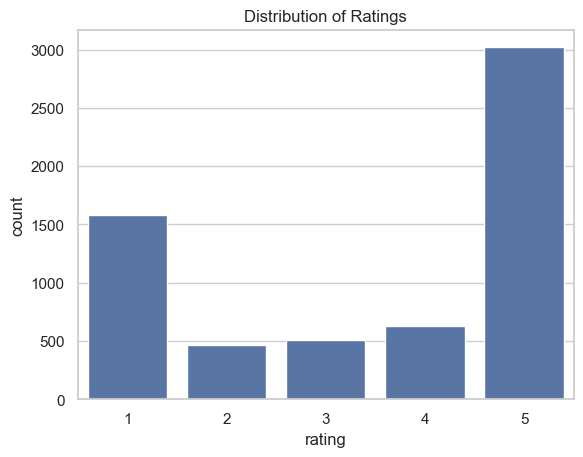

In [7]:
sns.countplot(x="rating", data=df)
plt.title("Distribution of Ratings")
plt.show()

The dataset contains 6210 reviews. There are 1582 1-star reviews, 467 2-star reviews, 508 3-star reviews, 632 4-star reviews and 3021 5-star reviews. This shows a bit of imbalanced distribution. The imbalance may have an effect on how the model preforms, especially if accuracy score is the only metric considered.

In [8]:
df["review_length"] = df["review_text"].str.len()

df["review_length"].describe()

count    6210.000000
mean       93.598390
std       130.661464
min         3.000000
25%        22.000000
50%        44.000000
75%       100.000000
max      1260.000000
Name: review_length, dtype: float64

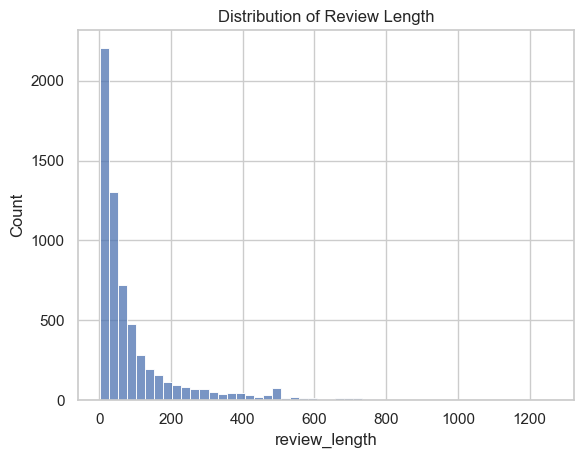

In [9]:
sns.histplot(df["review_length"], bins=50)
plt.title("Distribution of Review Length")
plt.show()

The average length of the reviews are 93 characters. The standar deviation is aproximately 131. This idicates that there is a large variation in length. Many are short, and some are very long. This variability may influence preproceccing decisions. 

In [10]:
df["review_text"].isnull().sum()

np.int64(0)

In [11]:
(df["review_text"].str.strip() == "").sum()

np.int64(0)

None of the reviews are empty, and it's not nessasary to remove any rows.

## 3. Preprocessing

In this step the text is cleaned before feature extaction. 

In [12]:
df["review_text"] = df["review_text"].str.lower()

In [13]:
import re

df["review_text"] = df["review_text"].apply(lambda x: re.sub(r"[^\w\s]", "", x))

In [14]:
import nltk
# nltk.download('stopwords')

In [15]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

In [16]:
df["review_text"] = df["review_text"].apply(
    lambda x: " ".join([word for word in x.split() if word not in stop_words])
)

## 4. Feature Engineering 

In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [47]:
TfidfVectorizer(max_features=5000, ngram_range=(1,2))

,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None
,analyzer,'word'
,stop_words,None
,token_pattern,'(?u)\\b\\w\\w+\\b'
,ngram_range,"(1, ...)"


In [48]:
X = vectorizer.fit_transform(df["review_text"])

In [49]:
y = df["rating"]

In [50]:
X.shape

(6210, 5000)

TF-IDF vectorization converts the review texts into numerical features. Each review is represented as a vector where the values reflect the importance of words in the dataset. This allows machine learning models to process textual data.

## 5. Models

In [51]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [52]:
X_train.shape

(4968, 5000)

The dataset is split into training and test sets in order to evaluate model performance on unseen data.

### 5.1 Model 1 - Logistic Regression (Classification) 

In [53]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [54]:
predictions = model.predict(X_test)

In [55]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, predictions)
accuracy

0.5966183574879227

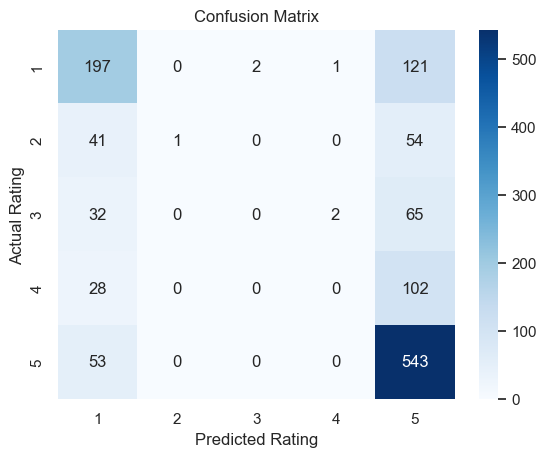

In [56]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, predictions)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[1,2,3,4,5],
    yticklabels=[1,2,3,4,5]
)

plt.xlabel("Predicted Rating")
plt.ylabel("Actual Rating")
plt.title("Confusion Matrix")
plt.show()

The model preforms well for the most frequent classes, in this case ratings 1 and 5, but struggles to predict the middle ratings. This is most likley due to imbalance in the dataset.

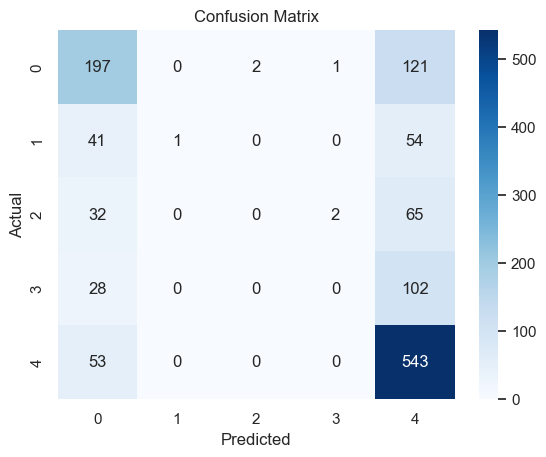

In [57]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, predictions)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

### 5.2 Model 2 Random Forest Classifier

In [65]:
from sklearn.ensemble import RandomForestClassifier

Importerer Random Forest Classifier modellen fra sckit-learn.

In [66]:
rf = RandomForestClassifier(n_estimators=100,random_state=42,n_jobs=-1)


Oppretter modellen med antall trær i skogen lik 100.

In [67]:
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           1       0.52      0.62      0.57       321
           2       0.00      0.00      0.00        96
           3       0.17      0.02      0.04        99
           4       0.16      0.02      0.04       130
           5       0.63      0.87      0.73       596

    accuracy                           0.58      1242
   macro avg       0.30      0.31      0.28      1242
weighted avg       0.47      0.58      0.51      1242



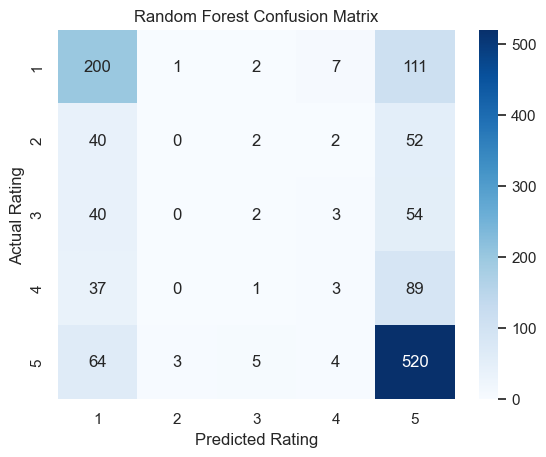

In [68]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test,y_pred_rf)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[1,2,3,4,5],
    yticklabels=[1,2,3,4,5])

plt.xlabel("Predicted Rating")
plt.ylabel("Actual Rating")
plt.title("Random Forest Confusion Matrix")
plt.show()

### 5.3 Model 3 Linear Regression (Regression)

In [69]:
from sklearn.linear_model import LinearRegression

In [70]:
lin_model = LinearRegression()

In [71]:
lin_model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [72]:
lin_predictions = lin_model.predict(X_test)

In [73]:
import numpy as np

lin_predictions_rounded = np.round(lin_predictions)
lin_predictions_rounded = np.clip(lin_predictions_rounded, 1, 5)

In [74]:
lin_accuracy = accuracy_score(y_test, lin_predictions_rounded)
lin_accuracy

0.38486312399355876

In [75]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

mse = mean_squared_error(y_test, lin_predictions)
mae = mean_absolute_error(y_test, lin_predictions)

mse, mae

(6.610998874148906, 1.7759851199446883)

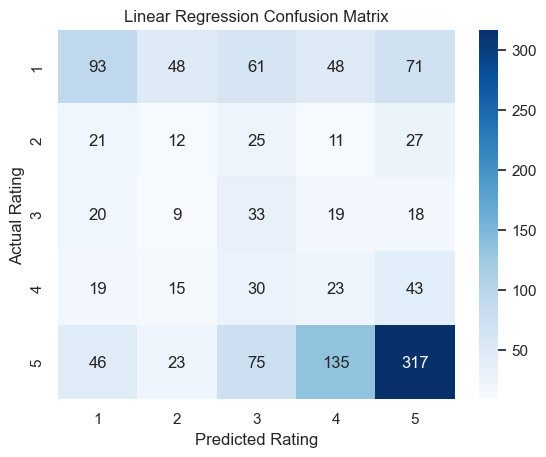

In [76]:
cm = confusion_matrix(y_test, lin_predictions_rounded)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[1,2,3,4,5],
    yticklabels=[1,2,3,4,5]
)

plt.xlabel("Predicted Rating")
plt.ylabel("Actual Rating")
plt.title("Linear Regression Confusion Matrix")
plt.show()

### 5.4 Model 4 LSTM Nerual Network

First we need to create Tokenization as TF-IDF can not be used directly with LSTM. LSTM needs Sequential ordering of the words not, bag-of-words.

In [77]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

ModuleNotFoundError: No module named 'tensorflow'

In [ ]:
max_words = 10000  
max_len = 100 

In [ ]:
tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(df["review_text"])

In [ ]:
sequences = tokenizer.texts_to_sequences(df["review_text"])
X_seq = pad_sequences(sequences, maxlen=max_len)

Create categorical classifications for the ratings 1-5.

In [ ]:

from tensorflow.keras.utils import to_categorical

In [ ]:
y = to_categorical(df["rating"] - 1)  # gjør om 1–5 → 0–4

Create train/test split.

In [78]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_seq, y, test_size=0.2, random_state=42
)

In [ ]:


from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

model = Sequential()

In [ ]:
# Embedding layer
model.add(Embedding(input_dim=max_words, output_dim=128, input_length=max_len))

# LSTM layer
model.add(LSTM(64, return_sequences=False))

# Regularization
model.add(Dropout(0.5))

# Output layer (5 klasser)
model.add(Dense(5, activation="softmax"))

model.compile(
    loss="categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

model.summary()




history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.2
)

Evaluation

In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)
print("Test accuracy:", accuracy)

## 6. Evaluation 

## 7. Discussion 

## 8. Conclusion 